# Week 2 Exercises

## Mathematical exercises: Pinhole camera

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import sys
sys.path.append('..')
from CV_functions import box3d, Pi, PiInv, projectpoints

### Ex 2.1

All points in bounds: False
Points out of bounds: 20
P1 projects to: [[100. 220.]]


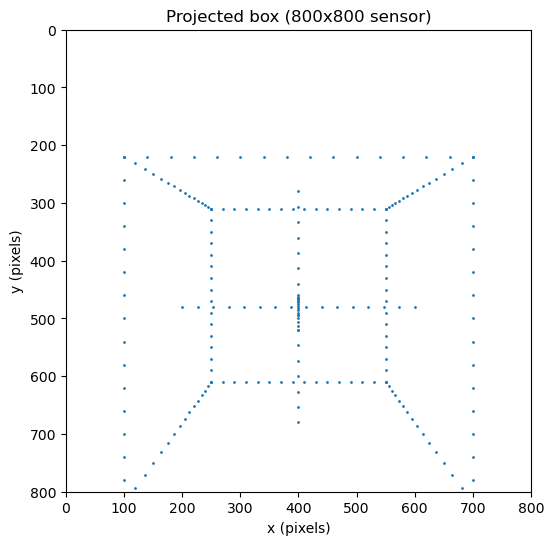

In [4]:
# Camera parameters
f = 600
delta_x = 400
delta_y = 400
K = np.array([[f, 0, delta_x],
              [0, f, delta_y],
              [0, 0,   1]])

R = np.eye(3)
t = np.array([0, 0.2, 1.5])

# Project the box
Q = box3d()
projected = projectpoints(K, R, t, Q)

# Check if all points are within the 800x800 image
in_bounds = (projected[0] >= 0) & (projected[0] <= 800) & \
            (projected[1] >= 0) & (projected[1] <= 800)
print(f"All points in bounds: {in_bounds.all()}")
print(f"Points out of bounds: {(~in_bounds).sum()}")

# Where does P1 = [-0.5, -0.5, -0.5] project to?
P1 = np.array([[-0.5], [-0.5], [-0.5]])
p1_proj = projectpoints(K, R, t, P1)
print(f"P1 projects to: {p1_proj.T}") # Should be [100, 220]

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(projected[0], projected[1], s=1)
plt.xlim(0, 800)
plt.ylim(0, 800)
plt.gca().invert_yaxis()  # image coordinates go top-down
plt.title('Projected box (800x800 sensor)')
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.show()

### Ex 2.2

In [ ]:
def projectpoints(K: np.ndarray, R: np.ndarray, t: np.ndarray, Q: np.ndarray, distCoeffs) -> np.ndarray:
    '''
    Camera matrix K
    Pose of the camera (R)otation, (t)ranslation
    3xn matrix Q, which is n points in 3D to be projected
    '''
    t = t.reshape(3, 1)
    return Pi(K @ (R @ Q + t))